## Business Context:
In the highly competitive grocery retail industry, understanding customer buying patterns is crucial for enhancing sales, increasing customer satisfaction, and improving profitability. By identifying frequently purchased item combinations, grocery stores can craft effective marketing strategies, optimize inventory management, and tailor promotions to meet customer needs. Leveraging Point of Sale (POS) data can unlock valuable insights that drive customer-centric offerings, such as combo packs, discounts, and targeted promotions, which can increase basket size and improve customer retention. This analysis aligns with business goals by maximizing revenue, reducing operational costs, and boosting customer loyalty.

## Objective:
As a business analyst, the goal is to analyze the POS transactional data to identify frequently purchased item combinations. Using association rule mining or similar techniques, the aim is to uncover patterns that will help the store create targeted combo offers and discounts, ultimately driving revenue growth by increasing customer purchases and average basket size.

## Data Description:
The dataset consists of transactional data from a grocery store, where each row represents a product purchased in a specific order. The columns in the dataset are as follows:

* Date: The date when the transaction took place.
* Order_id: A unique identifier for each customer order.
* Product: The individual item purchased in the transaction.

**Importing the necessary libraries**

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
from datetime import datetime

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To supress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
Data = pd.read_csv('dataset_group.csv')

In [3]:
# copying data to another variable to avoid any changes to original data
data = Data.copy()

## **Data Overview**

In [4]:
data.head(10)

,Date,Order_id,Product
0,01-01-2018,1,yogurt
1,01-01-2018,1,pork
2,01-01-2018,1,sandwich bags
3,01-01-2018,1,lunch meat
4,01-01-2018,1,all- purpose
5,01-01-2018,1,flour
6,01-01-2018,1,soda
7,01-01-2018,1,butter
8,01-01-2018,1,beef
9,01-01-2018,1,aluminum foil


In [5]:
data.tail(10)

,Date,Order_id,Product
20631,25-02-2020,1138,all- purpose
20632,25-02-2020,1138,sandwich bags
20633,25-02-2020,1138,toilet paper
20634,25-02-2020,1138,soda
20635,25-02-2020,1138,soda
20636,25-02-2020,1138,soda
20637,25-02-2020,1138,paper towels
20638,26-02-2020,1139,soda
20639,26-02-2020,1139,laundry detergent
20640,26-02-2020,1139,shampoo


In [6]:
data.shape

(20641, 3)

 #### The dataset has 20641 rows and 3 columns.

### Checking the data types of the columns for the dataset.

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20641 entries, 0 to 20640
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      20641 non-null  object
 1   Order_id  20641 non-null  int64 
 2   Product   20641 non-null  object
dtypes: int64(1), object(2)
memory usage: 483.9+ KB


### Checking for missing values

In [8]:
# checking for null values
data.isnull().sum()

Date        0
Order_id    0
Product     0
dtype: int64

* There are no null values in the dataset

### Checking for Duplicates

In [9]:
data.duplicated().sum()

4730

In [10]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,20641,603,08-02-2019,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_id,20641.000,NaN,NaN,NaN,575.986,328.557,1.000,292.000,581.000,862.000,1139.000
Product,20641,37,poultry,640,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
data['Product'] = data['Product'].str.lower()
data

,Date,Order_id,Product
0,01-01-2018,1,yogurt
1,01-01-2018,1,pork
2,01-01-2018,1,sandwich bags
3,01-01-2018,1,lunch meat
4,01-01-2018,1,all- purpose
...,...,...,...
20636,25-02-2020,1138,soda
20637,25-02-2020,1138,paper towels
20638,26-02-2020,1139,soda
20639,26-02-2020,1139,laundry detergent


## Exploratory Data Analysis

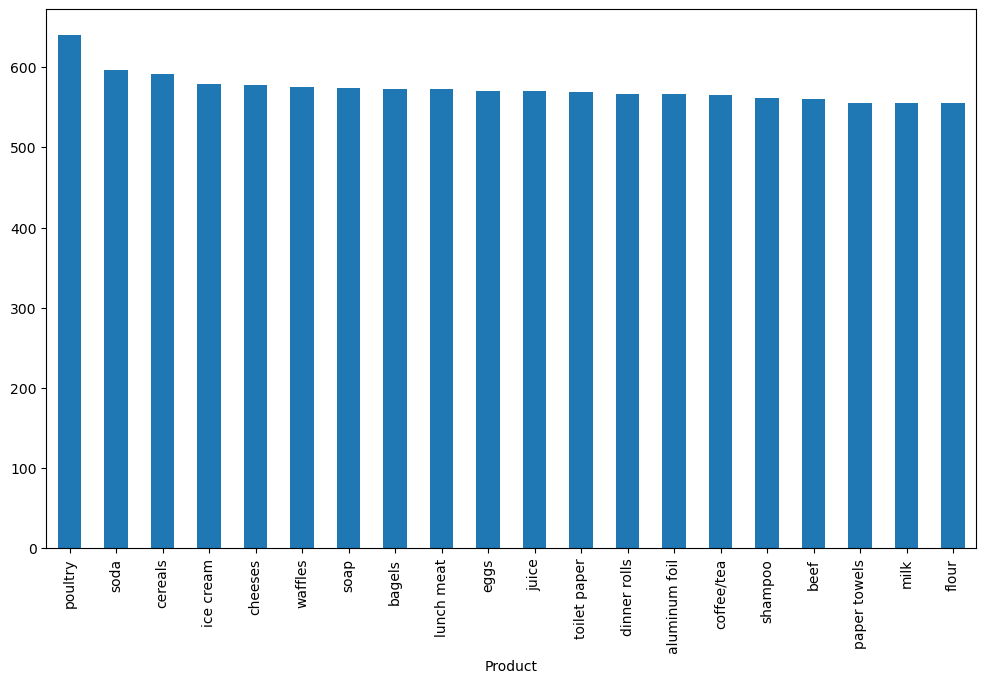

In [12]:
data['Product'].value_counts().sort_values(ascending=False).head(20).plot(kind='bar',figsize=(12,7));

In [13]:
basket=data.groupby(['Order_id', 'Product'])['Product'].count().unstack().reset_index().fillna(0).set_index('Order_id')

In [14]:
basket.head()

Product,all- purpose,aluminum foil,bagels,beef,butter,cereals,cheeses,coffee/tea,dinner rolls,dishwashing liquid/detergent,...,sandwich loaves,shampoo,soap,soda,spaghetti sauce,sugar,toilet paper,tortillas,waffles,yogurt
Order_id,,,,,,,,,,,,,,,,,,,,,
1,3.000,1.000,0.000,1.000,1.000,0.000,0.000,0.000,2.000,0.000,...,0.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000
2,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000,...,0.000,2.000,0.000,0.000,0.000,0.000,1.000,1.000,2.000,1.000
3,0.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000,1.000,0.000,...,1.000,1.000,2.000,1.000,3.000,0.000,2.000,0.000,0.000,0.000
4,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000
5,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,...,1.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000


In [15]:
basket.shape

(1139, 37)

In [16]:
def encode_zero_one(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

In [17]:
basket=basket.applymap(encode_zero_one)

In [18]:
basket.head(10)

Product,all- purpose,aluminum foil,bagels,beef,butter,cereals,cheeses,coffee/tea,dinner rolls,dishwashing liquid/detergent,...,sandwich loaves,shampoo,soap,soda,spaghetti sauce,sugar,toilet paper,tortillas,waffles,yogurt
Order_id,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,1,0,0,0,1,0,...,0,1,1,1,0,0,0,0,0,1
2,0,1,0,0,0,1,1,0,0,1,...,0,1,0,0,0,0,1,1,1,1
3,0,0,1,0,0,1,1,0,1,0,...,1,1,1,1,1,0,1,0,0,0
4,1,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
5,1,0,0,0,0,0,0,0,1,0,...,1,0,0,1,1,0,1,1,1,1
6,1,1,1,0,1,1,0,1,0,1,...,0,1,1,0,1,0,1,0,0,0
7,1,0,0,1,0,0,0,0,0,1,...,0,0,1,0,1,0,1,1,0,1
8,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0
9,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


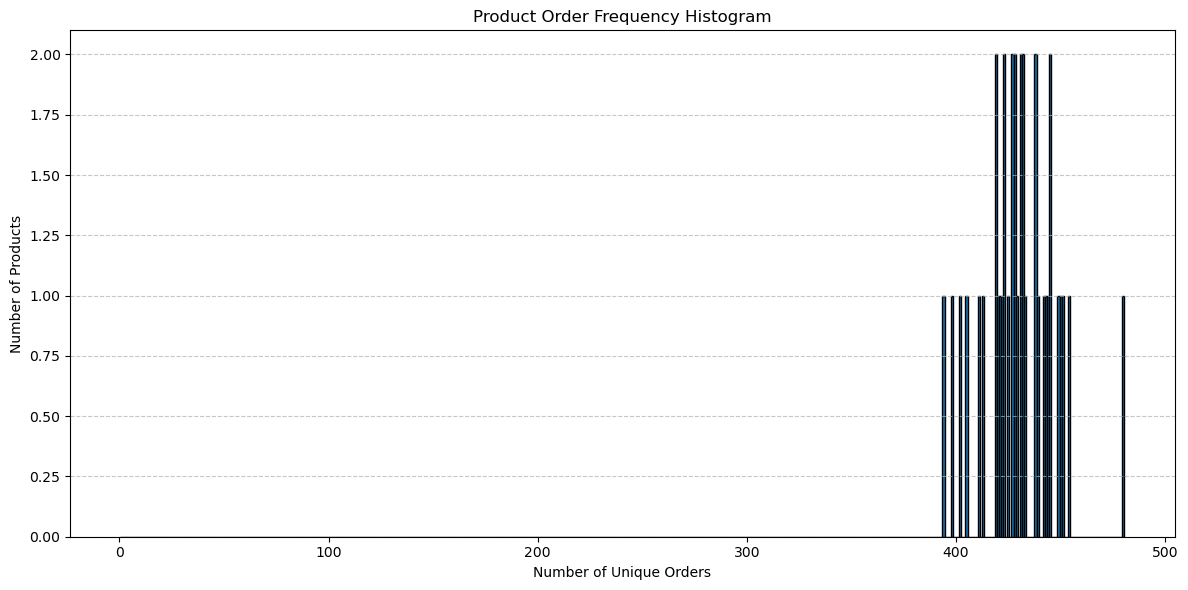

In [19]:

#Count the number of orders each product appears in
product_order_freq = data.groupby('Product')['Order_id'].nunique()

#Plot histogram of product frequencies across orders
plt.figure(figsize=(12, 6))
plt.hist(product_order_freq, bins=range(1, product_order_freq.max() + 2), edgecolor='black', align='left')
plt.title('Product Order Frequency Histogram')
plt.xlabel('Number of Unique Orders')
plt.ylabel('Number of Products')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


<Axes: xlabel='Date'>

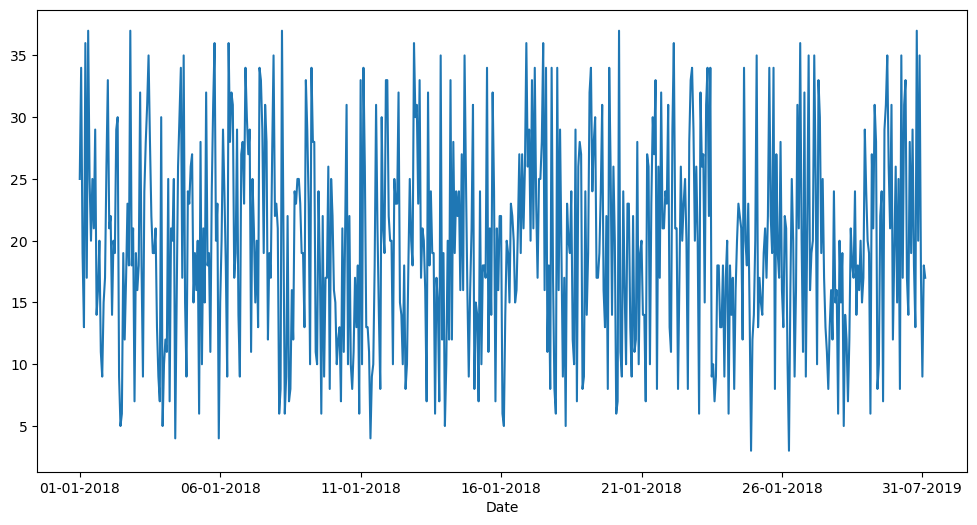

In [20]:
daily_product_variety = data.groupby('Date')['Product'].nunique()
daily_product_variety.plot(kind='line', figsize=(12,6))
